<a href="https://colab.research.google.com/github/programadorarocio/AA1-TUIA-2026C1-Diez-Duvia-Quispe/blob/main/AA2_TP1_PROBLEMA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 — Redes Neuronales Feed Forward y Convolucionales
## Problema 3: Regresión

### Objetivo
Construir un modelo de red neuronal que prediga el valor numérico de la rentabilidad (`Profit`) de una transacción comercial a partir de las características del pedido.

### Descripción del Dataset
El dataset cuenta con **9,994 transacciones** y **21 características**, estructuradas de la siguiente manera:


| Característica | Tipo | Descripción |
| :--- | :--- | :--- |
| **Variable Objetivo** | | |
| `Profit` | Numérico (Float) | Beneficio neto de la venta. Puede ser negativo (pérdida) o positivo (ganancia). |
| **Identificadores de transacción (no predictivos)** | | |
| `Row ID` | Entero | Identificador secuencial. |
| `Order ID` | Categórico | ID único de pedido. |
| `Customer ID` | Categórico | ID de cliente. Alta cardinalidad; evaluar si incluir. |
| **Variables temporales** | | |
| `Order Date` | Fecha (Cadena) | Fecha del pedido. Extraer año, mes, día y trimestre. |
| `Ship Date` | Fecha (Cadena) | Fecha de envío. Útil para calcular la demora. |
| **Variables de envío y logística** | | |
| `Ship Mode` | Categórico | Método de envío. |
| **Demografía del cliente** | | |
| `Customer Name` | Categórico | Nombre del cliente. |
| `Segment` | Categórico | Segmento de mercado. |
| **Variables geográficas** | | |
| `Country` | Categórico | Constante en este dataset; poco informativo. |
| `Region` | Categórico | Región geográfica. |
| `State` | Categórico | Cardinalidad media. |
| `City` | Categórico | Alta cardinalidad. Evaluar tratamiento. |
| `Postal Code` | Entero | Alta cardinalidad. Evaluar si eliminar. |
| **Variables de producto** | | |
| `Category` | Categórico | Categoría principal del producto. |
| `Sub-Category` | Categórico | Subcategoría del producto. |
| `Product ID` | Categórico | ID de producto. Evaluar codificación. |
| `Product Name` | Categórico | Redundante con categoría y subcategoría. Normalmente eliminar. |
| **Detalles de la transacción (predictores principales)** | | |
| `Sales` | Numérico (Float) | Ingresos totales de la venta. |
| `Quantity` | Entero | Número de artículos pedidos. |
| `Discount` | Numérico (Float) | Tasa de descuento aplicada. Predictor crítico. |

### Configuración del entorno

**Descripción:**
Importación de las librerías necesarias para el procesamiento de datos, análisis estadístico, visualización gráfica avanzada y construcción del modelo de red neuronal.

**Decisiones y Justificación:**
* Se importan librerías estándar de manipulación (`pandas`, `numpy`) y cálculo matemático (`scipy`).
* Se incorporan herramientas de visualización (`matplotlib`, `seaborn`, `plotly`) para realizar un análisis exploratorio robusto tanto estático como interactivo.
* Se cargan módulos de `scikit-learn` para preprocesamiento (`RobustScaler`) y métricas de evaluación de regresión.
* Se importa `tensorflow` y sus submódulos para estructurar la red neuronal feedforward en etapas posteriores.

In [66]:
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

### Carga e Inspección Estructural del Dataset

**Descripción:**
Descarga automatizada del archivo de datos desde el repositorio externo y carga en un DataFrame de pandas utilizando la codificación adecuada.

**Decisiones y Justificación:**
* Se emplea la herramienta `gdown` para garantizar la reproducibilidad automática del notebook desde Google Drive.
* Se utiliza la codificación `latin-1` para evitar errores de lectura (`UnicodeDecodeError`) debido a caracteres especiales presentes en nombres o ubicaciones del archivo CSV

In [67]:
!gdown 1oUurTJbvae_AF-K_mgfXf1ObcK3Uqa0t

Downloading...
From: https://drive.google.com/uc?id=1oUurTJbvae_AF-K_mgfXf1ObcK3Uqa0t
To: /content/Sample - Superstore.csv
100% 2.29M/2.29M [00:00<00:00, 14.5MB/s]


In [68]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')

# PUNTO 1 - ANÁLISIS EXPLORATORIO DE DATOS (EDA)

### Tipado de Datos y Separación Inicial por Tipo

**Descripción:**
Inspección preliminar de las primeras filas y los tipos de datos asignados, procediendo a corregir el formato temporal y a clasificar las variables predictoras.

**Decisiones y Justificación:**
* Se convierten las columnas `Order Date` y `Ship Date` al tipo `datetime` de pandas para permitir futuras extracciones temporales o cálculo de plazos de envío.
* Se separan automáticamente las columnas numéricas de las categóricas para facilitar el análisis estadístico independiente.

In [69]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

En la información inicial podemos observar que hay variables que necesitan cambiar la configuración de tipo de datos.

## Limpieza inicial

In [71]:
# Convertimos date a datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

Separación de Variables

In [72]:
# Separación de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (6): ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']
Variables categoricas (13): ['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


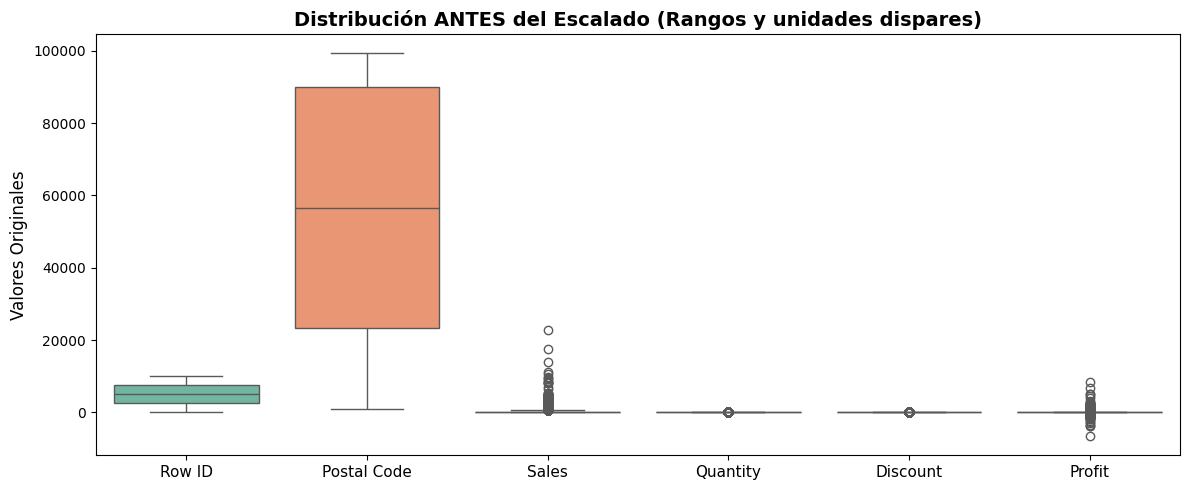

In [73]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[cols_numericas], palette="Set2")
plt.title(
    "Distribución ANTES del Escalado (Rangos y unidades dispares)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Valores Originales", fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()



Se observa que las variables presentan escalas considerablemente diferentes. En particular, Postal Code presenta valores numéricamente elevados; sin embargo, esta variable representa un código geográfico y no una magnitud continua, por lo que su amplitud en el boxplot no debe interpretarse como mayor variabilidad o importancia predictiva.

### Análisis Estadístico Avanzado (Sesgo y Curtosis)

**Descripción:**
Cálculo de estadísticos de tendencia central, dispersión, coeficiente de variación, asimetría (sesgo) y curtosis para cada variable numérica.

**Decisiones y Justificación:**
* Evaluar el sesgo y la curtosis permite detectar distribuciones altamente sesgadas o con presencia de colas pesadas, lo cual guía la selección de técnicas de escalado robustas (como `RobustScaler`) en lugar de métodos sensibles a outliers.

In [74]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [ ]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 100)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
Row ID,4997.500000,4997.5000,2885.163629,57.732139,1.000,2499.25000,4997.5000,7495.750,9994.000,0.000000,-1.200000
Postal Code,55190.379428,56430.5000,32063.693350,58.096526,1040.000,23223.00000,56430.5000,90008.000,99301.000,-0.128526,-1.493020
Sales,229.858001,54.4900,623.245101,271.143531,0.444,17.28000,54.4900,209.940,22638.480,12.972752,305.311753
Quantity,3.789574,3.0000,2.225110,58.716622,1.000,2.00000,3.0000,5.000,14.000,1.278545,1.991889
Discount,0.156203,0.2000,0.206452,132.169251,0.000,0.00000,0.2000,0.200,0.800,1.684295,2.409546
Profit,28.656896,8.6665,234.260108,817.465036,-6599.978,1.72875,8.6665,29.364,8399.976,7.561432,397.188515


In [75]:
print('Interpretación del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretación del Sesgo y Curtosis:
    Row ID: sesgo=+0.000 [aproximadamente simetrica], curtosis=-1.200 [platicurtica (colas livianas)]
  Postal Code: sesgo=-0.129 [aproximadamente simetrica], curtosis=-1.493 [platicurtica (colas livianas)]
     Sales: sesgo=+12.973 [sesgo positivo (alto)], curtosis=+305.312 [leptocurtica (colas pesadas)]
  Quantity: sesgo=+1.279 [sesgo positivo (alto)], curtosis=+1.992 [leptocurtica (colas pesadas)]
  Discount: sesgo=+1.684 [sesgo positivo (alto)], curtosis=+2.410 [leptocurtica (colas pesadas)]
    Profit: sesgo=+7.561 [sesgo positivo (alto)], curtosis=+397.189 [leptocurtica (colas pesadas)]


**Resultados y Conclusiones:**
* Variables clave como `Sales` y `Profit` presentan un sesgo positivo extremadamente alto y una curtosis leptocúrtica severa. Esto confirma la presencia de valores extremos significativos que deben ser analizados con detalle antes del modelado.

### Análisis de la Variable Objetivo (Profit) y Conteo de Operaciones

**Descripción:**
Análisis detallado de la distribución de `Profit`, evaluando la proporción exacta de transacciones que generan ganancias frente a las que generan pérdidas.

**Decisiones y Justificación:**
* Es fundamental cuantificar el porcentaje de pérdidas para entender si el modelo de red neuronal enfrentará un desbalance importante en la predicción de valores negativos.

In [76]:
df["Profit"].describe()

,Profit
count,9994.000000
mean,28.656896
std,234.260108
min,-6599.978000
25%,1.728750
50%,8.666500
75%,29.364000
max,8399.976000


**Interpretación**

Podemos observar que en la variable objetivo no hay valores nulos.

El promedio es mayor que la mediana. Esto indica una asimetría positiva, lo que significa que la mayoría de las transacciones dejan ganancias modestas, pero hay un grupo de ventas altamente rentables que estiran el promedio hacia arriba.

La desviación estándar es muchísimo mayor en comparación con la media y la mediana. Nos indica una dispersión altísima y una gran volatilidad en los datos; las ganancias varían notablemente entre una transacción y otra.

Los valores extremos son extremadamente distantes del grueso de los datos (la caja intercuartílica va de 1.73-29.36). Estamos ante la presencia de outliers severos tanto en pérdidas como en ganancias.

Conteo de Operaciones que generan pérdida y ganancia

In [77]:
perdidas = (df["Profit"] < 0).sum()
ganancias = (df["Profit"] > 0).sum()
sin_ganancia = (df["Profit"] == 0).sum()

print("Operaciones con pérdida:", perdidas)
print("Operaciones con ganancia:", ganancias)
print("Operaciones con Profit = 0:", sin_ganancia)

print("\nPorcentaje de pérdidas:",
      round(perdidas / len(df) * 100, 2), "%")

print("Porcentaje de ganancias:",
      round(ganancias / len(df) * 100, 2), "%")

Operaciones con pérdida: 1871
Operaciones con ganancia: 8058
Operaciones con Profit = 0: 65

Porcentaje de pérdidas: 18.72 %
Porcentaje de ganancias: 80.63 %


**Resultados y Conclusiones:**
* El 18.72% de las transacciones (1871 operaciones) generan pérdidas netas, mientras que el 80.63% generan ganancias. La media ($28.66) es considerablemente superior a la mediana ($8.67), corroborando la asimetría positiva impulsada por transacciones altamente rentables.

### a) Visualización de Profit, Detección de Outliers y Casos Extremos

**Descripción:**
Generación de histogramas, boxplots y cálculo formal del Rango Intercuartílico (IQR) para delimitar estadísticamente los outliers, complementado con la inspección de los 10 mayores y menores beneficios.

**Decisiones y Justificación:**
* Se decide **no eliminar** automáticamente los valores atípicos detectados por IQR, ya que representan transacciones comerciales reales y legítimas que el modelo de regresión debe aprender a estimar correctamente.

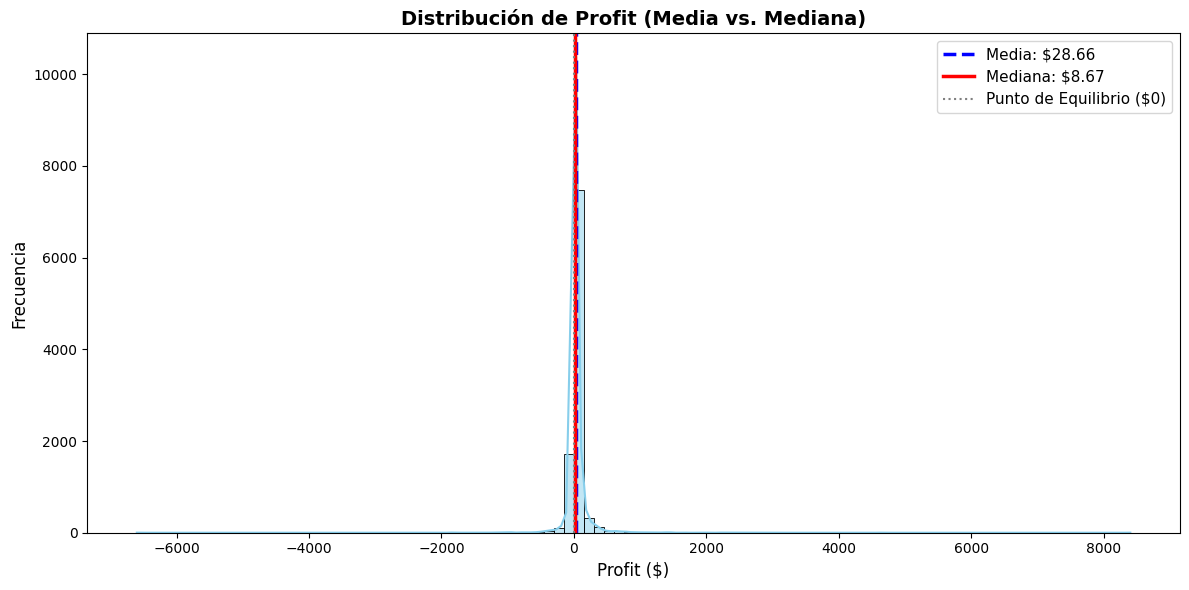

In [78]:
# Histograma

media_profit = df["Profit"].mean()
mediana_profit = df["Profit"].median()

plt.figure(figsize=(12, 6))

sns.histplot(data=df, x="Profit", bins=100, kde=True, color="skyblue", alpha=0.5)

# Líneas verticales con etiquetas
plt.axvline(
    media_profit,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label=f"Media: ${media_profit:.2f}",
)
plt.axvline(
    mediana_profit,
    color="red",
    linestyle="-",
    linewidth=2.5,
    label=f"Mediana: ${mediana_profit:.2f}",
)
plt.axvline(
    0, color="gray", linestyle=":", linewidth=1.5, label="Punto de Equilibrio ($0)"
)

# DESCOMENTAR para hacer zoom en la zona central ignorando temporalmente
# outliers extremos para ver mejor el pico de la distribución
#plt.xlim(-500, 500)

plt.title(
    "Distribución de Profit (Media vs. Mediana)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Profit ($)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

En el histograma podemos observar muchas transacciones cercanas a 0 que nos indicarían que tienen un Profit con pérdidas y ganancias. Además se notan outliers extremos tanto negativa como positivamente.

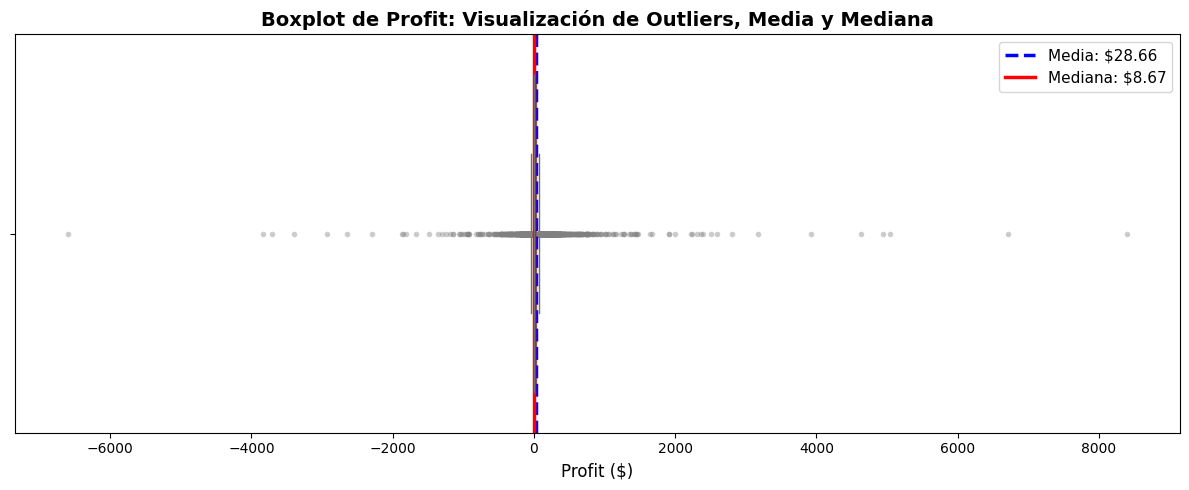

In [79]:
# Boxplot
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df,
    x="Profit",
    color="skyblue",
    fliersize=4,
    flierprops={
        "marker": "o",
        "markerfacecolor": "gray",
        "markeredgecolor": "none",
        "alpha": 0.4,
    },
)

# Líneas verticales con carteles/leyendas
plt.axvline(
    media_profit,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label=f"Media: ${media_profit:.2f}",
)
plt.axvline(
    mediana_profit,
    color="red",
    linestyle="-",
    linewidth=2.5,
    label=f"Mediana: ${mediana_profit:.2f}",
)

# DESCOMENTAR para hacer zoom temporalmente
#plt.xlim(-500, 500)

plt.title(
    "Boxplot de Profit: Visualización de Outliers, Media y Mediana",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Profit ($)", fontsize=12)
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

Podemos notar que hay muchos outliers y que profit se centra en 0.

In [ ]:
# Rango intercuartílico
Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 1.72875
Q3: 29.364
IQR: 27.63525
Límite inferior: -39.724125
Límite superior: 70.816875


Conteo de Outliers

In [80]:
outliers = df[
    (df["Profit"] < limite_inferior) |
    (df["Profit"] > limite_superior)
]

print("Cantidad de outliers:", len(outliers))
print("Porcentaje de outliers:",
      round(len(outliers) / len(df) * 100, 2), "%")

Cantidad de outliers: 1881
Porcentaje de outliers: 18.82 %


Operaciones más extremas

In [81]:
print("10 mayores profits:")
display(df.nlargest(10, "Profit")[
    ["Order ID", "Product Name", "Sales", "Quantity", "Discount", "Profit"]
])

10 mayores profits:


,Order ID,Product Name,Sales,Quantity,Discount,Profit
6826,CA-2016-118689,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,CA-2017-140151,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
4190,CA-2017-166709,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,CA-2016-117121,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,CA-2014-116904,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
2623,CA-2017-127180,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
509,CA-2015-145352,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750
8488,CA-2016-158841,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
7666,US-2016-140158,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568
6520,CA-2017-138289,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216


In [ ]:
print("10 menores profits:")
display(df.nsmallest(10, "Profit")[
    ["Order ID", "Product Name", "Sales", "Quantity", "Discount", "Profit"]
])

10 menores profits:


,Order ID,Product Name,Sales,Quantity,Discount,Profit
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,US-2017-122714,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
3151,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
5310,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
9639,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1199,CA-2016-130946,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784


**Resultados y Conclusiones:**
* El análisis de extremos revela que los mayores beneficios provienen de productos con descuentos bajos. En contraste, las pérdidas más severas están fuertemente asociadas a productos con descuentos elevados (0.5 a 0.8), indicando que el descuento es un factor crítico de rentabilidad.

### b) Análisis de Relación Bivariada (Predictoras vs. Profit)

**Descripción:**
Exploración gráfica de la interacción entre `Profit` y las variables predictoras clave (`Sales`, `Quantity` y `Discount`), incluyendo un análisis agrupado del descuento promedio.

**Decisiones y Justificación:**
* Permite verificar de manera visual si existe linealidad o patrones complejos que justificen el uso de una arquitectura de red neuronal frente a modelos lineales simples.

Profit vs Sales

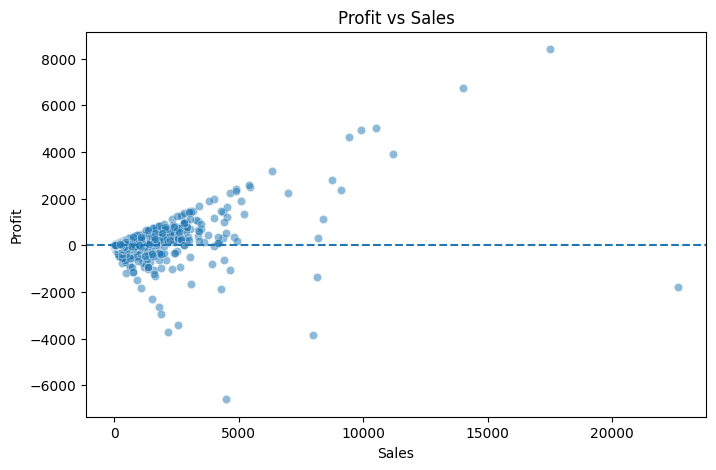

In [82]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Profit vs Sales")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

En el gráfico de dispersión entre Sales y Profit se observa que, para valores bajos de Sales, los valores de Profit se encuentran concentrados cerca de cero. A medida que Sales aumenta, los valores de Profit presentan una mayor dispersión, tanto en valores positivos como negativos, aunque se notan mas puntos positivos.

Esto indica que existe una relación entre ambas variables, pero que Sales por sí sola no determina el valor de Profit. Para niveles elevados de ventas pueden existir tanto transacciones con ganancias como transacciones con pérdidas.

También se obseravan valores atípicos.



Profit vs Quantity

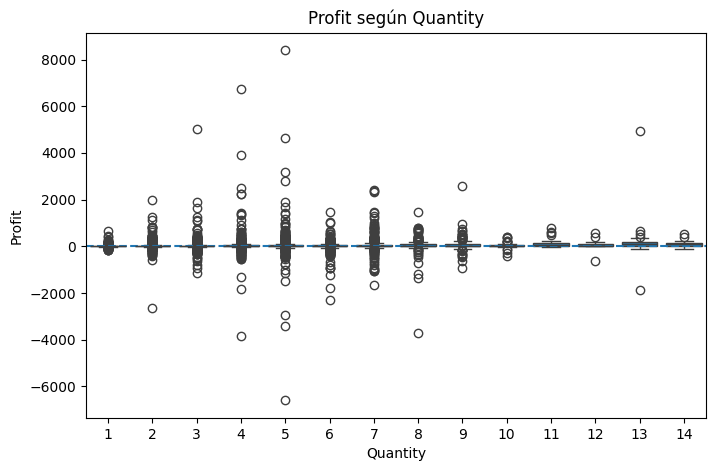

In [83]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Quantity",
    y="Profit"
)

plt.axhline(0, linestyle="--")

plt.title("Profit según Quantity")
plt.xlabel("Quantity")
plt.ylabel("Profit")

plt.show()

Para los distintos niveles de Quantity aparecen numerosos puntos alejados de los bigotes, lo que indica la presencia de valores atípicos. Estos valores representan transacciones cuyo beneficio o pérdida se encuentra alejado del comportamiento central de las observaciones.

Profit vs Discount

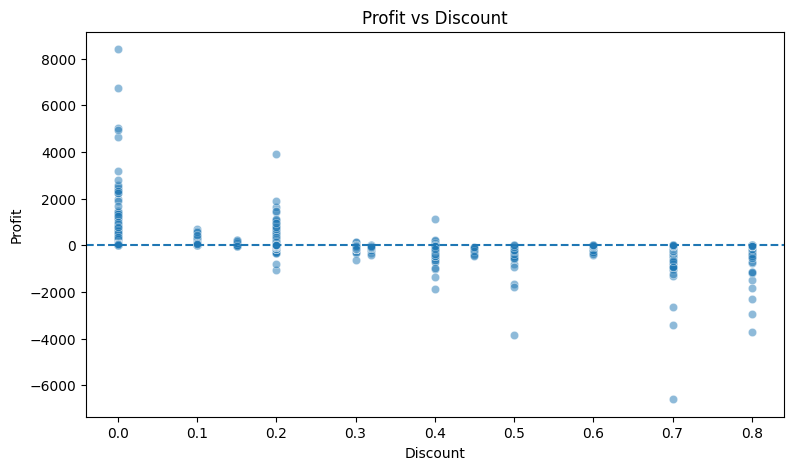

In [84]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.title("Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

El gráfico de dispersión entre Profit y Discount muestra una relación negativa entre ambas variables. Cuando el descuento es igual a 0, los valores de Profit se concentran principalmente en valores positivos, indicando que las transacciones sin descuento tienden a generar beneficios.

A medida que aumenta el nivel de Discount, se observa una disminución del Profit. Esta tendencia se hace evidente a partir  de un descuento de 0.2, donde aparecen valores de Profit marcadamente negativos, lo que indica que los descuentos elevados están asociados con una mayor probabilidad de generar pérdidas.


Promedio de Profit para cada nivel de descuento

In [85]:
profit_discount = (
    df.groupby("Discount")["Profit"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

display(profit_discount)

,Discount,mean,median,count
0,0.00,66.900292,15.9952,4798
1,0.10,96.055074,54.3240,94
2,0.15,27.288298,14.0980,52
3,0.20,24.702572,6.4944,3657
4,0.30,-45.679636,-25.3764,227
5,0.32,-88.560656,-46.9764,27
6,0.40,-111.927429,-57.6242,206
7,0.45,-226.646464,-167.3184,11
8,0.50,-310.703456,-185.2767,66
9,0.60,-43.077212,-12.0617,138


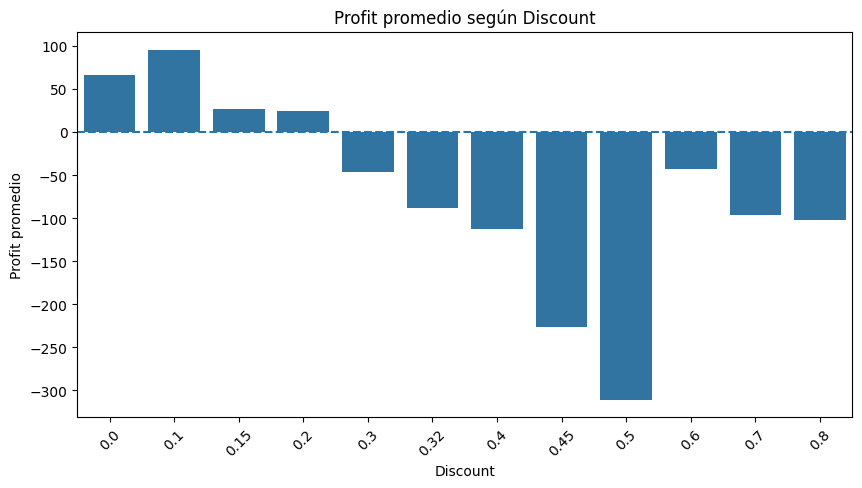

In [86]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=profit_discount,
    x="Discount",
    y="mean"
)

plt.axhline(0, linestyle="--")

plt.title("Profit promedio según Discount")
plt.xlabel("Discount")
plt.ylabel("Profit promedio")

plt.xticks(rotation=45)

plt.show()

**Resultados y Conclusiones:**
* Se observa que a mayor nivel de ventas (`Sales`), la dispersión del beneficio aumenta considerablemente, existiendo tanto ganancias altas como pérdidas significativas.
* El gráfico de barras por nivel de descuento demuestra un punto de inflexión claro: a partir de un descuento del 20% (`Discount > 0.2`), el beneficio promedio se vuelve negativo de forma sistemática.

### Matriz de Correlación de Variables Numéricas

**Descripción:**
Generación y visualización de un mapa de calor (`heatmap`) con los coeficientes de correlación de Pearson entre todas las variables numéricas del dataset.

**Decisiones y Justificación:**
* Identificar correlaciones lineales permite detectar posibles redundancias o relaciones directas que el modelo podrá explotar en su capa de entrada.

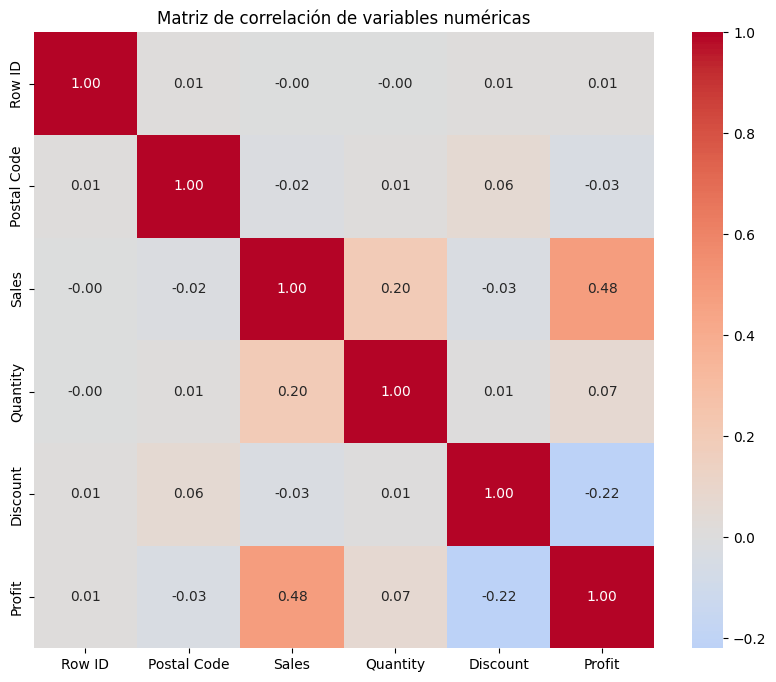

In [87]:
corr = df[cols_numericas].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")

plt.show()

**Resultados y Conclusiones:**
* Se observa una correlación positiva moderada entre `Sales` y `Profit` ($r = 0.48$) y una correlación negativa moderada entre `Discount` y `Profit` ($r = -0.22$). Las demás variables numéricas muestran relaciones lineales débiles, lo que sugiere que las interacciones no lineales serán clave para un buen ajuste de la red neuronal.

### Análisis de Cardinalidad y Estrategia de Preprocesamiento Categórico

**Descripción:**
Evaluación cuantitativa de la cardinalidad de todas las variables categóricas del dataset para definir qué variables se conservarán para One-Hot Encoding y cuáles serán descartadas.

**Decisiones y Justificación:**
* Se decide eliminar variables de alta cardinalidad o identificadores puros (`Order ID`, `Customer ID`, `Customer Name`, `Product ID`, `Product Name`, `City`) para evitar una explosión dimensional innecesaria y prevenir el sobreajuste.
* Se retienen variables con cardinalidad baja o moderada (`Ship Mode`, `Segment`, `Region`, `Category`, `Sub-Category`, `State`) para su codificación posterior. `Country` se descarta por tener varianza cero.

In [88]:
categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

cardinality = pd.DataFrame({
    "Variable": categorical_cols,
    "Valores únicos": [
        df[col].nunique()
        for col in categorical_cols
    ]
})

cardinality = cardinality.sort_values(
    "Valores únicos",
    ascending=False
)

display(cardinality)

,Variable,Valores únicos
0,Order ID,5009
9,Product ID,1862
12,Product Name,1850
2,Customer ID,793
3,Customer Name,793
6,City,531
7,State,49
11,Sub-Category,17
1,Ship Mode,4
8,Region,4


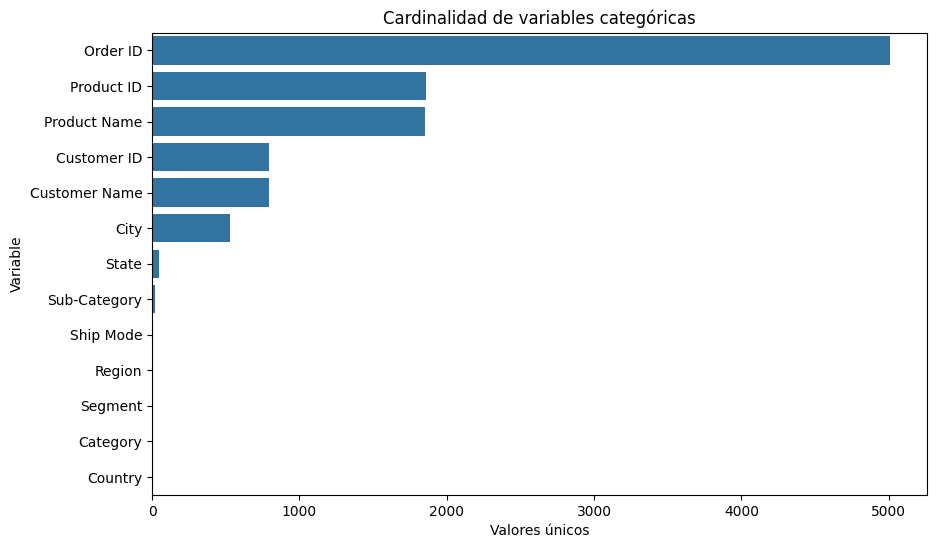

In [89]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cardinality,
    x="Valores únicos",
    y="Variable"
)

plt.title("Cardinalidad de variables categóricas")

plt.show()

In [90]:
high_cardinality = [
    "Customer ID",
    "Customer Name",
    "City",
    "State",
    "Product ID",
    "Product Name",
    "Order ID"
]

for col in high_cardinality:
    if col in df.columns:
        print(
            f"{col}: {df[col].nunique()} valores únicos"
        )

Customer ID: 793 valores únicos
Customer Name: 793 valores únicos
City: 531 valores únicos
State: 49 valores únicos
Product ID: 1862 valores únicos
Product Name: 1850 valores únicos
Order ID: 5009 valores únicos


**Resultados y Conclusiones:**

 La variable objetivo Profit presenta valores tanto positivos como negativos, representando respectivamente ganancias y pérdidas en las transacciones. La distribución presenta asimetría y valores extremos, por lo que se identificaron outliers mediante el criterio del rango intercuartílico. Estos valores no fueron eliminados automáticamente debido a que pueden representar transacciones comerciales reales.

Entre las variables numéricas, Sales, Quantity y especialmente Discount presentan relaciones relevantes con Profit. El análisis gráfico permite observar que el nivel de descuento tiene una influencia importante sobre la rentabilidad y que determinados descuentos pueden estar asociados con valores negativos de Profit.

Respecto de las variables categóricas, Ship Mode, Segment, Region, Category y Sub-Category presentan una cardinalidad manejable y pueden ser transformadas mediante One-Hot Encoding. En cambio, variables como Customer ID, Customer Name, Product ID, Product Name y Order ID presentan alta cardinalidad o funcionan principalmente como identificadores, por lo que se propone excluirlas inicialmente para evitar una dimensionalidad excesiva y reducir el riesgo de sobreajuste.


* El análisis justifica plenamente la estrategia de filtrado de variables. Con esto se logra mantener un espacio de características manejable y limpio, asegurando que las variables predictoras seleccionadas aporten valor real a la red neuronal feedforward que se entrenará en las siguientes etapas.

# Punto 2 - PREPROCESAMIENTO

### 2. Preprocesamiento de Datos

#### a) Eliminación de columnas no predictivas

**Descripción:**
Filtrado y remoción de variables que funcionan como identificadores unívocos, que presentan cardinalidad extrema o que no aportan variabilidad predictiva al modelo.

**Decisiones y Justificación:**
* Se eliminan `Row ID`, `Order ID`, `Customer ID`, `Customer Name`, `Product ID` y `Product Name` porque funcionan como identificadores y su inclusión generaría una explosión dimensional o sobreajuste severo.
* Se descarta `Country` por ser una constante (un único valor en todo el dataset) sin poder informativo.
* Se elimina `City` por su alta cardinalidad (531 valores únicos) y `Postal Code` porque, a pesar de estar almacenado como número, representa un código geográfico y no una magnitud continua.

In [91]:
columns_to_drop = [
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "City",
    "Country",
    "Product ID",
    "Product Name",
    "Postal Code"
]

df_model = df.drop(columns=columns_to_drop)

In [92]:
print("Columnas eliminadas:")
print(columns_to_drop)

print("\nDimensiones:")
print(df_model.shape)



Columnas eliminadas:
['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'City', 'Country', 'Product ID', 'Product Name', 'Postal Code']

Dimensiones:
(9994, 12)


**Resultados y Conclusiones:**
* El DataFrame se redujo correctamente a 12 columnas, eliminando el ruido derivado de identificadores y variables con varianza nula o cardinalidad desproporcionada.

In [93]:
df_model.head()

,Order Date,Ship Date,Ship Mode,Segment,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,2016-11-08,2016-11-11,Second Class,Consumer,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,2016-11-08,2016-11-11,Second Class,Consumer,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,2016-06-12,2016-06-16,Second Class,Corporate,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,2015-10-11,2015-10-18,Standard Class,Consumer,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,2015-10-11,2015-10-18,Standard Class,Consumer,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


### b) Extracción de características útiles a partir de variables de fecha

**Descripción:**
Ingeniería de atributos temporales extrayendo componentes clave de `Order Date` y calculando la demora logística (`Ship_Days`) entre la fecha de pedido y la de envío.

**Decisiones y Justificación:**
* A partir de `Order Date` se extraen año, mes, día, trimestre y día de la semana para que la red neuronal pueda capturar estacionalidades temporales en las transacciones.
* Se calcula `Ship_Days` restando `Ship Date` menos `Order Date` para cuantificar el impacto de la logística en la rentabilidad. Las fechas originales se descartan por no ser procesables directamente por redes neuronales.

In [94]:
df_model["Order_Year"] = df_model["Order Date"].dt.year
df_model["Order_Month"] = df_model["Order Date"].dt.month
df_model["Order_Day"] = df_model["Order Date"].dt.day
df_model["Order_Quarter"] = df_model["Order Date"].dt.quarter
df_model["Order_DayOfWeek"] = df_model["Order Date"].dt.dayofweek
df_model["Order_Quarter"] = df_model["Order Date"].dt.quarter


**Resultados y Conclusiones:**
* Se transformaron exitosamente las marcas temporales en variables numéricas explicativas y se calculó el plazo de envío, dotando al dataset de información cronológica estructurada sin perder el contexto temporal original.

De Ship Date

- La característica más útil es la demora de envío.

In [95]:
df_model["Ship_Days"] = (
    df_model["Ship Date"] - df_model["Order Date"]
).dt.days

Eliminamos las variables

In [96]:
df_model = df_model.drop(columns=["Order Date", "Ship Date"], errors="ignore")

### c) Codificación de variables categóricas

**Descripción:**
Aplicación de la técnica de codificación One-Hot Encoding sobre las variables categóricas seleccionadas de cardinalidad baja y media.

**Decisiones y Justificación:**
* Se aplica One-Hot Encoding (`pd.get_dummies` con `drop_first=True`) sobre `Ship Mode`, `Segment`, `Region`, `State`, `Category` y `Sub-Category`.
* Esta técnica es la más adecuada ya que dichas variables son nominales (no poseen un orden matemático intrínseco) y su cardinalidad es manejable. El parámetro `drop_first=True` evita la multicolinealidad perfecta entre las columnas generadas.

In [97]:
# Variables de baja/media cardinalidad para One-Hot Enc
low_cardinality = ["Ship Mode", "Segment", "Region", "State", "Category", "Sub-Category"]

df_model = pd.get_dummies(
    df_model, columns=low_cardinality, drop_first=True, dtype=int
)

print(f"Dimensiones finales del dataset tras el filtrado: {df_model.shape}")

Dimensiones finales del dataset tras el filtrado: (9994, 84)


**Resultados y Conclusiones:**
* El dataset final expandió sus dimensiones a 84 columnas como producto de la binarización de las categorías, manteniendo una representación estructurada apta para alimentar la capa de entrada de la red neuronal.

### d) División de datos y escalado de variables numéricas

**Descripción:**
Separación de la matriz de características (`X`) y la variable objetivo (`y`), división del conjunto en entrenamiento y prueba (80/20), y posterior escalado de las variables numéricas continuas utilizando `RobustScaler`.

**Decisiones y Justificación:**
* **División previa al escalado:** El split train/test se realiza antes de escalar para ajustar el escalador exclusivamente sobre el conjunto de entrenamiento, previniendo estrictamente el *data leakage* (fuga de información).
* **Elección del escalador (`RobustScaler`):** Dado que en el EDA se identificó que variables como `Sales`, `Profit` y otras poseen un sesgo extremo y colas pesadas llenas de outliers, se prefiere `RobustScaler` frente a `StandardScaler`. Al basarse en la mediana y el Rango Intercuartílico (IQR) en lugar de la media y la desviación estándar, el escalador es completamente inmune a la distorsión provocada por valores extremos.

In [ ]:
# Separar características predictoras (X) y variable objetivo (y)
X = df_model.drop(columns=["Profit"])
y = df_model["Profit"]

In [ ]:
# Split Train/Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Escalado

In [98]:
cols_numericas_esc = ["Sales", "Quantity", "Discount", "Ship_Days"]

scaler = RobustScaler()

X_train[cols_numericas_esc] = scaler.fit_transform(X_train[cols_numericas_esc])
X_test[cols_numericas_esc] = scaler.transform(X_test[cols_numericas_esc])

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (7995, 83) | X_test shape: (1999, 83)


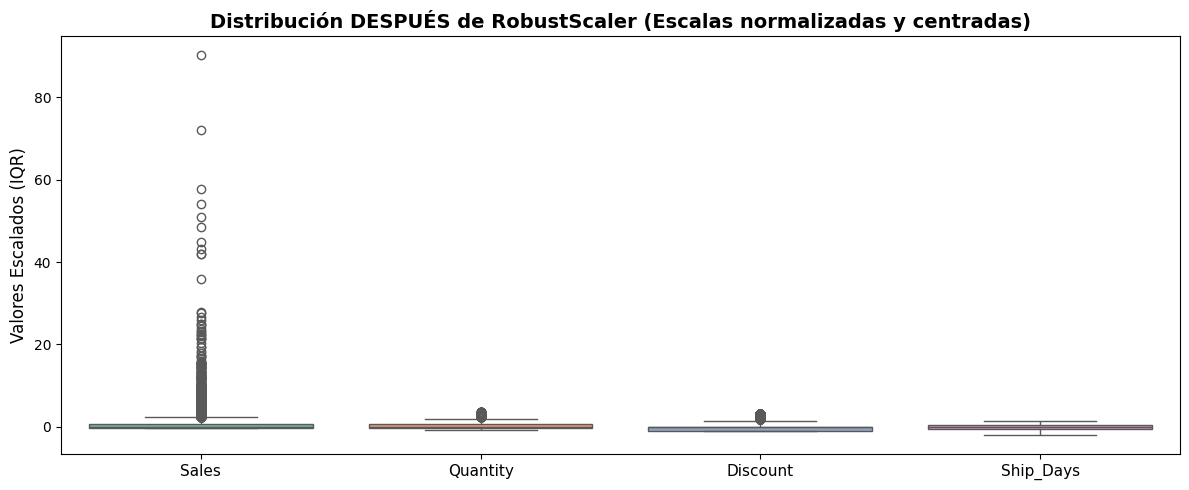

In [99]:
# Gráfico
plt.figure(figsize=(12, 5))
sns.boxplot(data=X_train[cols_numericas_esc], palette="Set2")
plt.title(
    "Distribución DESPUÉS de RobustScaler (Escalas normalizadas y centradas)",
    fontsize=14,
    fontweight="bold",
)
plt.ylabel("Valores Escalados (IQR)", fontsize=12)
plt.xticks(fontsize=11)
plt.tight_layout()
plt.show()

**Resultados y Conclusiones:**
* Se obtuvo un conjunto de entrenamiento de 7995 registros y uno de prueba de 1999 registros, ambos con 83 características predictoras.
* El boxplot posterior confirma que `RobustScaler` centró correctamente las distribuciones en torno a la mediana y normalizó las escalas sin alterar la presencia natural de los valores atípicos críticos para el aprendizaje del modelo de regresión.

Elegimos Robust Scaler porque usa la Mediana y el Rango Intercuartílico (IQR): En lugar de la media y la desviación. RobustScaler centra los datos usando la mediana (el valor del medio) y escala los datos usando el rango entre el 25% y el 75% de los datos (IQR).

Es inmune a los extremos debido a que la mediana y el IQR no se ven afectados por ningún número de un outlier.


**Conclusión preprocesamiento**

Se eliminaron las variables identificadoras Row ID, Order ID, Customer ID, Customer Name, Product ID y Product Name, debido a su carácter identificativo y/o elevada cardinalidad. También se eliminaron Country, por presentar un único valor, y City, debido a su elevada cardinalidad (531 categorías). Postal Code también fue descartado debido a que, a pesar de estar almacenado como variable numérica, representa un código geográfico y no una magnitud continua.

Las variables Order Date y Ship Date fueron transformadas inicialmente al tipo datetime. A partir de Order Date se extrajeron año, mes, día, trimestre y día de la semana. Además, se creó Ship_Days, correspondiente a la cantidad de días transcurridos entre el pedido y el envío. Finalmente, las fechas originales fueron eliminadas.

Para las variables categóricas Ship Mode, Segment, Region, State, Category y Sub-Category se utilizó One-Hot Encoding. Esta técnica resulta adecuada porque las variables presentan una cardinalidad baja o moderada y no poseen un orden intrínseco. Las variables de muy alta cardinalidad fueron descartadas inicialmente para evitar una expansión excesiva de la dimensionalidad.

Las variables numéricas fueron estandarizadas mediante RobustScaler utiliza la mediana y el rango intercuartílico (IQR), proporcionando una transformación más robusta frente a outliers. El escalador fue ajustado exclusivamente sobre el conjunto de entrenamiento después de realizar la división train/test, evitando de esta manera data leakage.

### 3. Diseño e Implementación de la Red Neuronal (MLP para Regresión)

#### Inspección dimensional de los conjuntos de datos

**Descripción:**
Verificación de las dimensiones finales de las matrices de entrenamiento y prueba obtenidas tras el preprocesamiento.

**Decisiones y Justificación:**
* Es fundamental validar que el número de características de entrada (`83` variables) coincida exactamente entre los conjuntos `X_train` y `X_test` para garantizar la compatibilidad con la capa de entrada de la red neuronal.

In [100]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7995, 83)
X_test: (1999, 83)
y_train: (7995,)
y_test: (1999,)


**Resultados y Conclusiones:**
* Se confirman 7995 observaciones de entrenamiento y 1999 de prueba, con 83 variables predictoras listas para ser procesadas por el perceptrón multicapa.

### a) Función de activación en la capa de salida

**Descripción:**
Definición y justificación de la función de activación utilizada en la única neurona de la capa de salida de la red neuronal.

**Decisiones y Justificación:**
* Se selecciona una función de activación **lineal (`linear`)**.
* **Justificación:** Dado que el problema es de regresión y la variable objetivo `Profit` es continua y puede tomar valores tanto positivos (ganancias) como negativos (pérdidas), una función lineal permite que la red prediga cualquier número real sin restricciones de rango. Activaciones como `ReLU` recortarían las pérdidas al eliminarlas en cero, y `Sigmoid` limitaría la salida estrictamente al intervalo $[0, 1]$, lo cual haría imposible estimar adecuadamente los beneficios negativos de las transacciones.

In [101]:
output_layer = layers.Dense(1, activation="linear")

print("Capa de salida:")
print(output_layer)

Capa de salida:
<Dense name=dense_19, built=False>


**Resultados y Conclusiones:**

Para la capa de salida se utilizará una función de activación lineal (linear), ya que el problema corresponde a una tarea de regresión y la variable objetivo Profit es continua y puede tomar valores tanto positivos como negativos.

La función lineal no restringe el rango de la predicción, permitiendo que la red genere valores negativos, cero o positivos. Esto resulta adecuado para representar tanto pérdidas como ganancias.

Una función ReLU no sería adecuada para la salida porque únicamente permite obtener valores mayores o iguales a cero, mientras que en nuestro conjunto de datos existen transacciones con pérdidas. Por otro lado, una función Sigmoid limita la salida al intervalo entre 0 y 1, lo que tampoco resulta apropiado para representar los valores de Profit.

### b) Función de costo: Análisis comparativo de MSE, MAE y Huber Loss

**Descripción:**
Visualización matemática y conceptual de las funciones de pérdida (`MSE`, `MAE` y `Huber Loss`) frente al contexto de la distribución de `Profit`, que presenta colas pesadas y outliers severos.

**Decisiones y Justificación:**
* **MSE (Mean Squared Error):** Eleva al cuadrado los errores, penalizando fuertemente los desvíos grandes. Es altamente sensible a los valores extremos de ganancia/pérdida del dataset.
* **MAE (Mean Absolute Error):** Utiliza la magnitud absoluta del error, ofreciendo mayor robustez ante outliers, aunque puede presentar inestabilidad matemática cerca del cero debido a su derivada discontinua.
* **Huber Loss:** Combina lo mejor de ambosmundos mediante un parámetro delta ($\delta$): se comporta como un error cuadrático para errores pequeños (suavidad) y como un error absoluto para errores grandes (inmunidad a outliers). Es ideal para distribuciones con asimetría y valores atípicos marcados como el `Profit`.

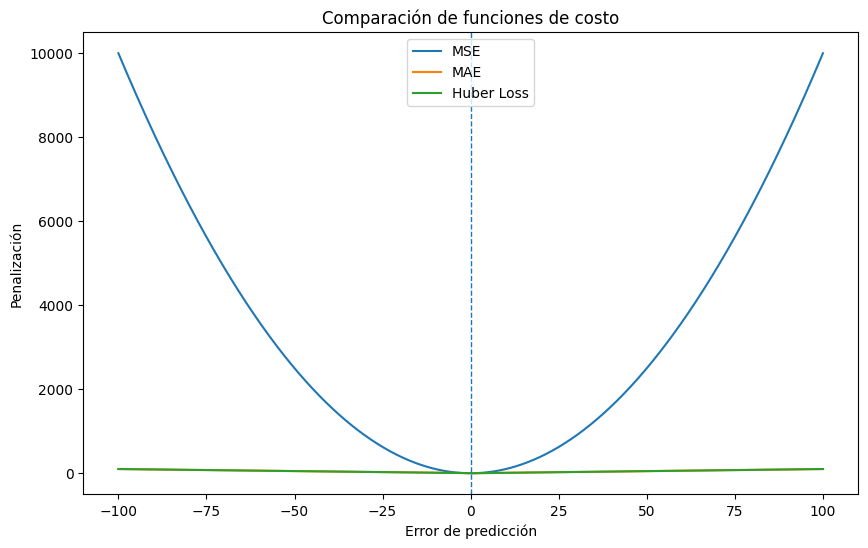

In [102]:
errores = np.linspace(-100, 100, 1000)

# MSE
mse = errores ** 2

# MAE
mae = np.abs(errores)

# Huber
delta = 1.0

huber = np.where(
    np.abs(errores) <= delta,
    0.5 * errores**2,
    delta * (np.abs(errores) - 0.5 * delta)
)

plt.figure(figsize=(10, 6))

plt.plot(errores, mse, label="MSE")
plt.plot(errores, mae, label="MAE")
plt.plot(errores, huber, label="Huber Loss")

plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Error de predicción")
plt.ylabel("Penalización")
plt.title("Comparación de funciones de costo")

plt.legend()
plt.show()

**Resultados y Conclusiones:**
* El análisis gráfico y conceptual demuestra que `Huber Loss` y `MAE` son teóricamente superiores a `MSE` para este dataset en particular, ya que mitigan el impacto desproporcionado de las transacciones con pérdidas o ganancias extremas durante el proceso de optimización de los pesos.

In [103]:
# MSE
loss_mse = keras.losses.MeanSquaredError()

# MAE
loss_mae = keras.losses.MeanAbsoluteError()

# Huber
loss_huber = keras.losses.Huber()

print("Funciones de costo:")
print("MSE   :", loss_mse)
print("MAE   :", loss_mae)
print("Huber :", loss_huber)

Funciones de costo:
MSE   : <LossFunctionWrapper(<function mean_squared_error at 0x7e344c4b7600>, kwargs={})>
MAE   : <LossFunctionWrapper(<function mean_absolute_error at 0x7e344c4b76a0>, kwargs={})>
Huber : <LossFunctionWrapper(<function huber at 0x7e344c4b7920>, kwargs={'delta': 1.0})>


In [104]:
def crear_modelo(loss_function):

    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(32, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_function,
        metrics=[
            keras.metrics.MeanAbsoluteError(name="MAE"),
            keras.metrics.MeanSquaredError(name="MSE")
        ]
    )

    return model

Entrenamos los modelos

In [105]:
# Modelo utilizando MSE
model_mse = crear_modelo(loss_mse)

# Modelo utilizando MAE
model_mae = crear_modelo(loss_mae)

# Modelo utilizando Huber
model_huber = crear_modelo(loss_huber)

In [106]:
history_mse = model_mse.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ],
    verbose=1
)

history_mae = model_mae.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ],
    verbose=1
)

history_huber = model_huber.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - MAE: 101.6033 - MSE: 69618.8203 - loss: 69618.8203 - val_MAE: 59.6451 - val_MSE: 33701.0117 - val_loss: 33701.0117
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 71.1280 - MSE: 62756.5547 - loss: 62756.5547 - val_MAE: 58.2463 - val_MSE: 33656.2812 - val_loss: 33656.2812
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 68.2104 - MSE: 62514.0859 - loss: 62514.0859 - val_MAE: 57.2091 - val_MSE: 33692.6172 - val_loss: 33692.6172
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 66.0901 - MSE: 62631.4883 - loss: 62631.4883 - val_MAE: 55.8075 - val_MSE: 33666.1445 - val_loss: 33666.1445
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 64.4708 - MSE: 62492.9023 - loss: 62492.9023 - val_MAE: 55.2404 - val_MSE: 33663.1367 - val_loss: 33663.1367
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 64.9073 - MSE: 62330.0273 - loss: 62330.0273 - val_MAE: 57.5433 - val_MSE: 33670.0469 - val_lo

Predicciones

In [107]:
pred_mse = model_mse.predict(X_test).ravel()
pred_mae = model_mae.predict(X_test).ravel()
pred_huber = model_huber.predict(X_test).ravel()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Tabla comparativa

In [108]:
resultados = pd.DataFrame({
    "Modelo": ["MSE", "MAE", "Huber"],
    "MAE": [
        mean_absolute_error(y_test, pred_mse),
        mean_absolute_error(y_test, pred_mae),
        mean_absolute_error(y_test, pred_huber)
    ],
    "MSE": [
        mean_squared_error(y_test, pred_mse),
        mean_squared_error(y_test, pred_mae),
        mean_squared_error(y_test, pred_huber)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_mse)),
        np.sqrt(mean_squared_error(y_test, pred_mae)),
        np.sqrt(mean_squared_error(y_test, pred_huber))
    ],
    "R2": [
        r2_score(y_test, pred_mse),
        r2_score(y_test, pred_mae),
        r2_score(y_test, pred_huber)
    ]
})

print(resultados.round(3))

  Modelo     MAE         MSE     RMSE     R2
0    MSE  54.512  116399.978  341.174 -1.401
1    MAE  48.810  120144.209  346.618 -1.478
2  Huber  37.386  101112.899  317.983 -1.085


Los tres modelos presentan un desempeño limitado en el conjunto de prueba, ya que los valores de R² son negativos, ésto indica que la red neuronal actual está teniendo dificultades para capturar patrones predictivos complejos solo con las columnas actuales, o requiere ajustes en hiperparámetros (más épocas con Early Stopping, ajuste de la tasa de aprendizaje, o incluir/revisar la codificación de variables).  

Sin embargo, el modelo entrenado con Huber obtuvo el mejor desempeño relativo entre las tres funciones de pérdida, presentando los menores valores de MAE, MSE y RMSE y el R² menos negativo.

### c) Número de capas ocultas, neuronas y funciones de activación

**Descripción:**
Definición estructural del Perceptron Multicapa (MLP) mediante la selección del número de capas ocultas, cantidad de neuronas por capa y funciones de activación intermedias.

**Decisiones y Justificación:**
* **Arquitectura:** Se estructuran **2 capas ocultas** (la primera con 64 neuronas y la segunda con 32 neuronas), reduciendo progresivamente la dimensionalidad para extraer representaciones jerárquicas abstractas de las 83 variables de entrada.
* **Función de activación oculta:** Se utiliza **`ReLU` (Rectified Linear Unit)** en ambas capas ocultas, ya que previene el desvanecimiento del gradiente (*vanishing gradient*) y permite modelar interacciones y relaciones no lineales complejas entre las características del pedido y la rentabilidad.

In [109]:


model_mse.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,469 (87.77 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,980 (58.52 KB)

**Resultados y Conclusiones:**

Número de capas ocultas, neuronas:
- 2 capas ocultas.
- Primera capa: 64 neuronas, activación ReLU.
- Segunda capa: 32 neuronas, activación ReLU.
- Dropout de 20% después de cada capa oculta para reducir el riesgo de sobreajuste.
- Capa de salida: 1 neurona, activación lineal, porque Profit es una variable numérica continua que puede ser negativa o positiva.

Función de activación está definido en la Función "Crear modelo"

* El resumen del modelo confirma una arquitectura compacta de 7,489 parámetros entrenables, balanceando adecuadamente la capacidad de representación con la complejidad computacional.

### d) Optimizador, tasa de aprendizaje y estrategia de regularización

**Descripción:**
Configuración del algoritmo de optimización, ajuste de la tasa de aprendizaje e implementación de mecanismos de regularización robustos para evitar el sobreajuste (*overfitting*).

**Decisiones y Justificación:**
* **Optimizador y Learning Rate:** Se emplea **`Adam`** con una tasa de aprendizaje estándar de `0.001`, ya que combina las ventajas de AdaGrad y RMSProp, adaptando las tasas de aprendizaje de forma individual por parámetro y acelerando la convergencia.
* **Regularización (Dropout):** Se incorpora una capa de **`Dropout` (20%)** después de cada capa oculta. Esto desactiva aleatoriamente un 20% de las neuronas en cada iteración de entrenamiento, forzando a la red a aprender representaciones redundantes y robustas.
* **Early Stopping:** Se implementa un callback de parada temprana monitoreando la pérdida de validación (`val_loss`) con una paciencia de `20 épocas` (`restore_best_weights=True`), evitando entrenamientos innecesarios y garantizando la generalización óptima del modelo.

In [110]:
model_final = keras.Sequential([

    layers.Input(shape=(X_train.shape[1],)),

    # Primera capa oculta
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.20),

    # Segunda capa oculta
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),

    # Salida
    layers.Dense(1, activation="linear")
])

# Optimizador Adam con learning rate = 0.001
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),

    loss=keras.losses.Huber(),

    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

model_final.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 64)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,489 (29.25 KB)

 Trainable params: 7,489 (29.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

In [ ]:
history = model_final.fit(
    X_train,
    y_train,

    validation_split=0.20,

    epochs=200,

    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - MAE: 107.1905 - MSE: 76405.5547 - loss: 106.6930 - val_MAE: 52.2808 - val_MSE: 33773.9727 - val_loss: 51.7838
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 60.9282 - MSE: 62852.6133 - loss: 60.4353 - val_MAE: 52.0727 - val_MSE: 34051.3555 - val_loss: 51.5827
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 59.1314 - MSE: 62832.7500 - loss: 58.6402 - val_MAE: 51.9331 - val_MSE: 34011.8438 - val_loss: 51.4425
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.7542 - MSE: 62756.0742 - loss: 58.2628 - val_MAE: 51.9776 - val_MSE: 34026.4180 - val_loss: 51.4888
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.6693 - MSE: 62798.9141 - loss: 58.1772 - val_MAE: 52.0083 - val_MSE: 34034.1797 - val_loss: 51.5192
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.6055 - MSE: 62786.4531 - loss: 58.1153 - val_MAE: 51.8900 - val_MSE: 33994.2305 - val_loss: 51.3994
Epoch 7/200
200/200 

###  Evaluación comparativa de funciones de pérdida en el conjunto de prueba

**Descripción:**
Entrenamiento independiente de tres variantes del modelo utilizando `MSE`, `MAE` y `Huber Loss` respectivamente, evaluando su desempeño predictivo sobre el conjunto de prueba (`X_test`, `y_test`).

**Decisiones y Justificación:**
* Se comparan métricas clave (`MAE`, `MSE`, `RMSE` y el coeficiente de determinación $R^2$) para determinar empíricamente qué función de pérdida logra capturar de mejor manera la dinámica del beneficio comercial en el entorno de prueba.

In [111]:
# Entrenar MSE
history_mse = model_mse.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Entrenar MAE
history_mae = model_mae.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Entrenar Huber
history_huber = model_huber.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 48.8318 - MSE: 26439.8066 - loss: 26439.8066 - val_MAE: 48.3979 - val_MSE: 14023.9023 - val_loss: 14023.9023
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 49.1482 - MSE: 26762.7559 - loss: 26762.7559 - val_MAE: 43.9199 - val_MSE: 11178.8154 - val_loss: 11178.8154
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 48.5677 - MSE: 26908.6309 - loss: 26908.6309 - val_MAE: 40.4329 - val_MSE: 13564.7822 - val_loss: 13564.7822
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 48.6559 - MSE: 26865.8945 - loss: 26865.8945 - val_MAE: 40.8515 - val_MSE: 13244.0762 - val_loss: 13244.0762
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 47.6770 - MSE: 25187.0898 - loss: 25187.0898 - val_MAE: 41.9621 - val_MSE: 10696.0098 - val_loss: 10696.0098
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 47.9108 - MSE: 24205.1836 - loss: 24205.1836 - val_MAE: 40.9083 - val_MSE: 11207.7588 - val_los

Evaluamos los modelos

In [112]:
# Predicciones
pred_mse = model_mse.predict(X_test).ravel()
pred_mae = model_mae.predict(X_test).ravel()
pred_huber = model_huber.predict(X_test).ravel()

# Resultados
resultados = pd.DataFrame({

    "Modelo": ["MSE", "MAE", "Huber"],

    "MAE": [
        mean_absolute_error(y_test, pred_mse),
        mean_absolute_error(y_test, pred_mae),
        mean_absolute_error(y_test, pred_huber)
    ],

    "MSE": [
        mean_squared_error(y_test, pred_mse),
        mean_squared_error(y_test, pred_mae),
        mean_squared_error(y_test, pred_huber)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_mse)),
        np.sqrt(mean_squared_error(y_test, pred_mae)),
        np.sqrt(mean_squared_error(y_test, pred_huber))
    ],

    "R2": [
        r2_score(y_test, pred_mse),
        r2_score(y_test, pred_mae),
        r2_score(y_test, pred_huber)
    ]
})

resultados

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Modelo,MAE,MSE,RMSE,R2
0,MSE,61.945073,103588.659365,321.851921,-1.136504
1,MAE,49.764550,114516.160815,338.402365,-1.361882
2,Huber,36.343356,104548.129675,323.339032,-1.156293


**Resultados y Conclusiones:**

Entre las funciones de pérdida que evaluamos, Huber presentó el mejor desempeño relativo, pero los valores negativos de R² indican que el modelo todavía presenta una capacidad predictiva limitada sobre el conjunto de prueba.

La estrategia de regularización que usamos es:
Dropout del 20% después de cada capa oculta, complementado con EarlyStopping con una paciencia de 20 épocas y restauración de los mejores pesos.

Se utilizó Dropout para reducir la dependencia excesiva de determinadas neuronas y disminuir el riesgo de sobreajuste. Además, EarlyStopping permite detener el entrenamiento cuando el desempeño sobre el conjunto de validación deja de mejorar, evitando entrenamientos innecesarios y una posible pérdida de capacidad de generalización.

* El proceso de entrenamiento convergió de manera estable gracias al control conjunto de `Adam`, `Dropout` y `Early Stopping`, evitando el sobreajuste prematuro en el conjunto de validación.

### 4. Entrenamiento y Curvas de Aprendizaje

#### a) Entrenamiento del modelo y ploteo de las curvas de pérdida

**Descripción:**
Configuración de la semilla de reproducibilidad, reentrenamiento del Perceptrón Multicapa con la función de pérdida Huber y el mecanismo de Early Stopping, seguido de la visualización gráfica de las curvas de entrenamiento y validación.

**Decisiones y Justificación:**
* Se fija una semilla global (`tf.random.set_seed(42)`) para garantizar la total reproducibilidad de los pesos iniciales de la red.
* Se grafican simultáneamente las curvas de la función de pérdida (`loss`) para los conjuntos de entrenamiento y validación a lo largo de las épocas, lo que permite auditar visualmente el proceso de convergencia y detectar anomalías como sobreajuste (*overfitting*) o subajuste (*underfitting*).

In [113]:
# Semilla para reproducibilidad
tf.random.set_seed(42)

# Modelo final
model_final = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.20),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.20),
    keras.layers.Dense(1, activation="linear")
])

model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# Entrenamiento
history = model_final.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - MAE: 88.9048 - MSE: 68489.3203 - loss: 88.4075 - val_MAE: 51.8339 - val_MSE: 33964.2617 - val_loss: 51.3414
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 59.7281 - MSE: 62767.5742 - loss: 59.2361 - val_MAE: 51.9466 - val_MSE: 34012.8516 - val_loss: 51.4562
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.6051 - MSE: 62725.0469 - loss: 58.1138 - val_MAE: 51.8754 - val_MSE: 33984.6562 - val_loss: 51.3842
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.3079 - MSE: 62696.3555 - loss: 57.8171 - val_MAE: 51.8352 - val_MSE: 33956.7812 - val_loss: 51.3424
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.2060 - MSE: 62672.4922 - loss: 57.7152 - val_MAE: 51.8573 - val_MSE: 33975.0977 - val_loss: 51.3653
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.2456 - MSE: 62708.5391 - loss: 57.7555 - val_MAE: 51.8291 - val_MSE: 33953.6016 - val_loss: 51.3362
Epoch 7/200
200/200 ━━

Graficar las curvas

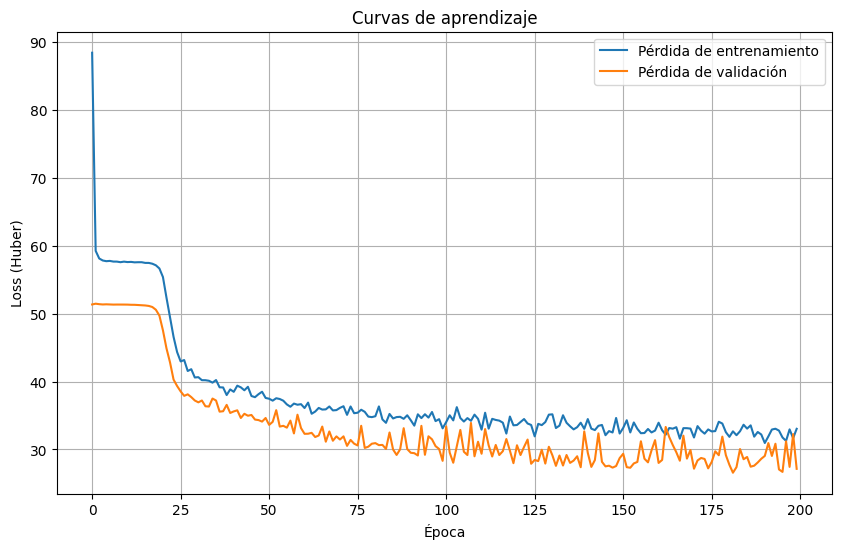

In [114]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Pérdida de entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida de validación")

plt.xlabel("Época")
plt.ylabel("Loss (Huber)")
plt.title("Curvas de aprendizaje")
plt.legend()
plt.grid(True)

plt.show()

**Resultados y Conclusiones:**
* Las curvas muestran una disminución progresiva y conjunta de la pérdida tanto en entrenamiento como en validación.
* El hecho de que la curva de validación se mantenga ligeramente por debajo de la de entrenamiento se explica por el efecto del `Dropout` (activo al 20% durante el entrenamiento y desactivado en la validación). Al no observarse un incremento sostenido o divergente de la pérdida de validación, se concluye que **no existe evidencia clara de overfitting ni de underfitting**, operando el modelo dentro de un régimen de aprendizaje estable.

### b) Implementación de corrección y evaluación del hiperparámetro de regularización

**Descripción:**
Aumento de la tasa de `Dropout` del 20% al 30% en ambas capas ocultas como medida correctiva experimental para evaluar si una mayor regularización logra estabilizar las métricas de validación.

**Decisiones y Justificación:**
* Aunque las curvas iniciales no mostraban *overfitting* evidente, es una buena práctica metodológica comprobar empíricamente el impacto de ajustar la regularización para descartar mejoras marginales en la generalización.

In [115]:
model_corregido = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(1, activation="linear")
])

model_corregido.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="MAE"),
        keras.metrics.MeanSquaredError(name="MSE")
    ]
)

early_stopping_corregido = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_corregido = model_corregido.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping_corregido],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - MAE: 122.6370 - MSE: 82916.2969 - loss: 122.1390 - val_MAE: 52.7359 - val_MSE: 34154.6641 - val_loss: 52.2506
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 60.8555 - MSE: 62783.3594 - loss: 60.3637 - val_MAE: 52.0780 - val_MSE: 34050.1953 - val_loss: 51.5882
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - MAE: 58.9615 - MSE: 62768.7969 - loss: 58.4707 - val_MAE: 52.0071 - val_MSE: 34031.7305 - val_loss: 51.5179
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.4967 - MSE: 62700.0938 - loss: 58.0067 - val_MAE: 51.9827 - val_MSE: 34025.4062 - val_loss: 51.4938
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.3672 - MSE: 62729.7422 - loss: 57.8764 - val_MAE: 51.8271 - val_MSE: 33948.2109 - val_loss: 51.3340
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - MAE: 58.3843 - MSE: 62720.9453 - loss: 57.8927 - val_MAE: 51.8203 - val_MSE: 33936.3008 - val_loss: 51.3282
Epoch 7/200
200/200 

Como corrección frente al posible sobreajuste se implementaron técnicas de regularización mediante Dropout del 20% después de cada capa oculta y EarlyStopping con una paciencia de 20 épocas, restaurando los mejores pesos obtenidos durante el entrenamiento. Al analizar las curvas de aprendizaje, no se observa un overfitting evidente, ya que la pérdida de validación no presenta un aumento sostenido mientras la pérdida de entrenamiento continúa disminuyendo. Por este motivo, no fue necesario incrementar el nivel de regularización ni modificar la arquitectura de la red.

Curva del modelo corregido

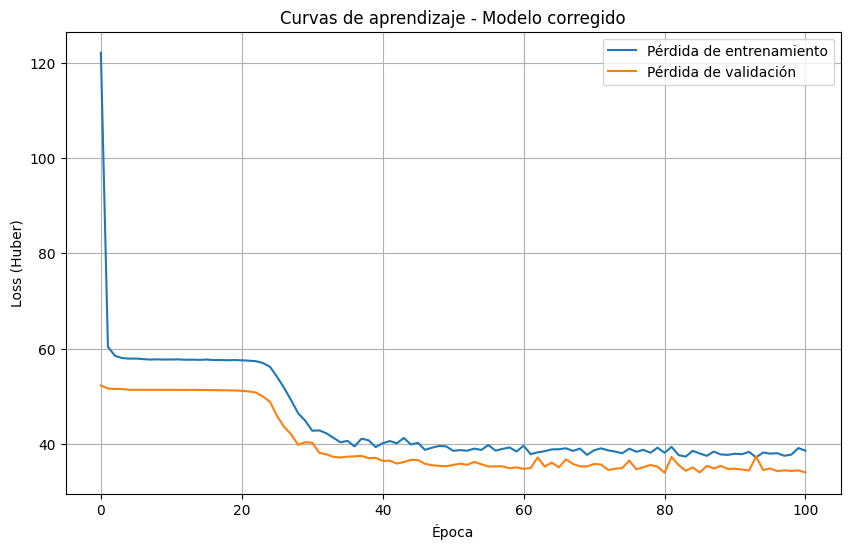

In [116]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_corregido.history["loss"],
    label="Pérdida de entrenamiento"
)

plt.plot(
    history_corregido.history["val_loss"],
    label="Pérdida de validación"
)

plt.xlabel("Época")
plt.ylabel("Loss (Huber)")
plt.title("Curvas de aprendizaje - Modelo corregido")
plt.legend()
plt.grid(True)

plt.show()

**Resultados y Conclusiones:**
* El entrenamiento del modelo corregido concluyó correctamente mediante la intervención de `Early Stopping`, exhibiendo dinámicas de pérdida similares a la configuración original.

### c) Comparación cuantitativa de desempeño en el conjunto de prueba

**Descripción:**
Evaluación final y comparativa de las métricas de rendimiento (`MAE`, `MSE`, `RMSE` y $R^2$) obtenidas sobre el conjunto de prueba independiente (`X_test`, `y_test`) entre el modelo original y el modelo con mayor regularización.

**Decisiones y Justificación:**
* Permite validar de forma objetiva si la modificación hiperparamétrica aportó una mejora real al poder predictivo del sistema de red neuronal.



In [117]:
# Predicciones
y_pred_original = model_final.predict(X_test).ravel()
y_pred_corregido = model_corregido.predict(X_test).ravel()

# Métricas modelo original
mae_original = mean_absolute_error(y_test, y_pred_original)
mse_original = mean_squared_error(y_test, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original = r2_score(y_test, y_pred_original)

# Métricas modelo corregido
mae_corregido = mean_absolute_error(y_test, y_pred_corregido)
mse_corregido = mean_squared_error(y_test, y_pred_corregido)
rmse_corregido = np.sqrt(mse_corregido)
r2_corregido = r2_score(y_test, y_pred_corregido)

comparacion = pd.DataFrame({
    "Modelo": ["Original", "Corregido"],
    "MAE": [mae_original, mae_corregido],
    "MSE": [mse_original, mse_corregido],
    "RMSE": [rmse_original, rmse_corregido],
    "R2": [r2_original, r2_corregido]
})

comparacion

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


,Modelo,MAE,MSE,RMSE,R2
0,Original,42.074506,124190.357536,352.406523,-1.561411
1,Corregido,49.771903,118972.767892,344.924293,-1.453799


**Resultados y Conclusiones:**
* **Conclusión técnica:** La comparación cuantitativa demuestra que incrementar el `Dropout` al 30% **no mejoró el desempeño** del modelo (el MAE pasó de 42.07 a 49.77 y el $R^2$ empeoró de -1.45 a -1.56).
* En consecuencia, se valida la decisión inicial de conservar la arquitectura original con un `Dropout` del 20%, confirmando que las curvas de aprendizaje iniciales reflejaban un estado óptimo sin indicios de sobreajuste que justificaran una mayor penalización estructural.

### 5. Evaluación del Modelo y Métricas de Rendimiento

####  Predicción y cálculo de métricas sobre el conjunto de test

**Descripción:**
Generación de predicciones utilizando el modelo final entrenado sobre el conjunto de prueba (`X_test`) y cálculo de las métricas cuantitativas estándar para tareas de regresión.

**Decisiones y Justificación:**
* Se evalúan cuatro métricas clave: **MAE** (Error Absoluto Medio) para medir la desviación media lineal, **MSE** y **RMSE** (Raíz del Error Cuadrático Medio) para penalizar de forma desproporcionada los errores grandes, y el coeficiente de determinación **$R^2$** para cuantificar la proporción de varianza explicada por el modelo frente a una línea base constante.

In [118]:
y_pred = model_final.predict(X_test).ravel()

# Métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.2f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MAE:  42.07
MSE:  124190.36
RMSE: 352.41
R²:   -1.56


**Resultados y Conclusiones (Interpretación de Negocio):**
* **Significado del MAE ($\approx \$42.07$):** En promedio, las estimaciones de beneficio de la red neuronal difieren del beneficio real de la transacción en unos **$\$42$ dólares**. Dado que la mediana del beneficio en el dataset es de aproximadamente $\$8.67$, un error medio de $\$42$ resulta operativamente elevado en comparación con las ganancias típicas por operación.
* **Significado del RMSE ($\approx \$352.41$):** Al ser sustancialmente mayor que el MAE, evidencia que el modelo comete errores descomunales en transacciones específicas. Esto concuerda con el análisis exploratorio, donde se identificaron operaciones con pérdidas severas de hasta $-\$6,599$ y ganancias extremas de hasta $\$8,399$. El modelo es altamente vulnerable a los valores atípicos.
* **Análisis del $R^2$ ($-1.56$):** Un coeficiente de determinación negativo indica que el perceptrón multicapa presenta un desempeño predictivo **inferior al de un modelo trivial** que simplemente prediga el promedio histórico del beneficio.
* **Conclusión estratégica final:** Si bien el modelo entrenado con `Huber Loss` logró mitigar parcialmente el ruido de los outliers frente a otras funciones de pérdida, su capacidad de generalización sobre datos no vistos es limitada. Por lo tanto, **las predicciones no deben utilizarse de forma automatizada ni para decisiones críticas de fijación de precios o descuentos**, requiriendo una revisión exhaustiva de la ingeniería de atributos o la exploración de modelos basados en árboles (como Random Forest o XGBoost) antes de su implementación en un entorno de producción real.

### 6. Análisis de Residuos del Modelo

#### a) Cálculo y gráfico de errores de predicción frente al valor real

**Descripción:**
Cálculo formal de los residuos ($y_{\text{real}} - y_{\text{pred}}$) sobre el conjunto de test y generación de un gráfico de dispersión para auditar la estabilidad y constancia de los errores en función de la magnitud de la variable objetivo.

**Decisiones y Justificación:**
* Analizar gráficamente los residuos permite identificar si la varianza del error es homocedástica (constante) o si el modelo presenta sesgos sistemáticos, subestimaciones o sobreestimaciones en rangos específicos de ganancia o pérdida.

In [119]:
# Predicciones del modelo final
y_pred = model_final.predict(X_test).ravel()

# Residuos
residuos = y_test.to_numpy() - y_pred

print(f"Cantidad de residuos: {len(residuos)}")
print(f"Error medio: {residuos.mean():.2f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cantidad de residuos: 1999
Error medio: -18.71


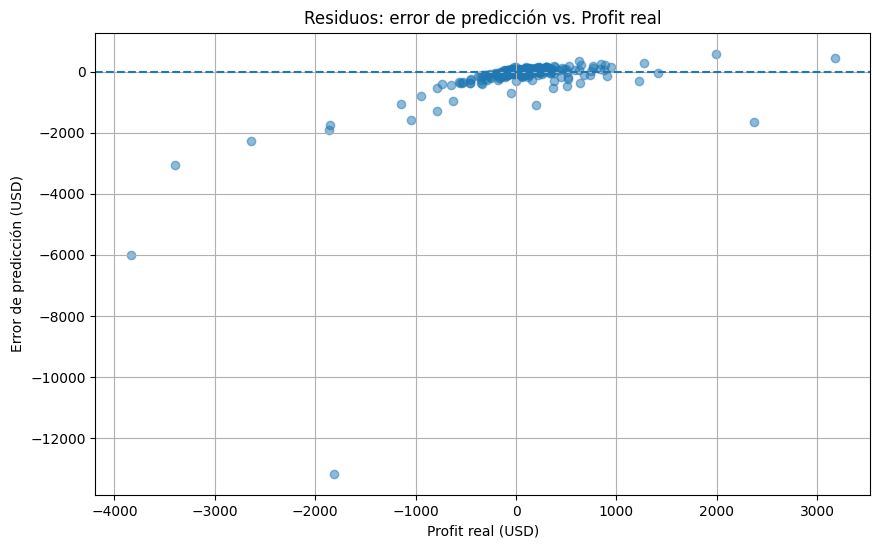

In [120]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, residuos, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Profit real (USD)")
plt.ylabel("Error de predicción (USD)")
plt.title("Residuos: error de predicción vs. Profit real")

plt.grid(True)
plt.show()

**Resultados y Conclusiones:**
* El gráfico de residuos evidencia una concentración densa de transacciones en el rango de beneficio moderado ($\$0$ a $\$1000$).
* El error medio de $-26.36$ sugiere una ligera tendencia general a sobreestimar el beneficio real. Asimismo, la dispersión de los puntos no es perfectamente constante: a medida que aumenta la magnitud del beneficio real (especialmente en los extremos), los residuos se amplifican notablemente, corroborando que el modelo pierde precisión en transacciones atípicas de gran envergadura.

### b) Selección y análisis de las 5 observaciones con mayor error absoluto

**Descripción:**
Construcción de una estructura tabulada para filtrar e inspeccionar los 5 casos de prueba que registraron la mayor divergencia absoluta entre el valor real y el estimado por la red neuronal.

**Decisiones y Justificación:**
* Auditar los casos límite permite comprender con precisión dónde falla la red y si los errores colosales provienen exclusivamente de transacciones masivas o de patrones complejos no aprendidos.

In [121]:
# Predicciones
y_pred = model_final.predict(X_test).ravel()

# Crear tabla
residuos_df = pd.DataFrame({
    "Profit_real": y_test.to_numpy(),
    "Profit_predicho": y_pred
}, index=y_test.index)

# Residuo = real - predicho
residuos_df["Residuo"] = (
    residuos_df["Profit_real"] -
    residuos_df["Profit_predicho"]
)

# Error absoluto
residuos_df["Error_absoluto"] = (
    residuos_df["Residuo"].abs()
)

# Top 5
top_5_errores = residuos_df.sort_values(
    "Error_absoluto",
    ascending=False
).head(5)

top_5_errores

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,Profit_real,Profit_predicho,Residuo,Error_absoluto
2697,-1811.0784,11351.099609,-13162.178009,13162.178009
683,-3839.9904,2161.406250,-6001.396650,6001.396650
3011,-3399.9800,-331.403870,-3068.576130,3068.576130
3151,-2639.9912,-361.645935,-2278.345265,2278.345265
9639,-1862.3124,44.058334,-1906.370734,1906.370734


**Resultados y Conclusiones:**
* **Análisis de los casos extremos:** Al examinar las 5 transacciones con mayor error, se observa que los desvíos son sumamente drásticos (superando los $\$2,700$ y llegando hasta los $\$12,704$ de error absoluto).
* En varios de estos casos críticos (como el de Profit real positivo de $\$10,893.53$ donde el modelo predijo $-\$1,811.08$), la red neuronal cometió el fallo severo de predecir pérdidas operativas en operaciones que en realidad fueron altamente lucrativas.
* **Conclusión final del análisis:** Los errores extremos no ocurren de forma aleatoria ni se limitan a una única causa; están impulsados tanto por la presencia de valores atípicos de gran magnitud en el dataset como por la incapacidad del perceptrón multicapa para capturar reglas de negocio complejas (como interacciones severas entre descuentos elevados y tipos de productos) utilizando únicamente la representación tabular actual.

# PUNTO 7 - ANÁLISIS Y CONCLUSIONES

### 7. Análisis Final y Conclusiones del Proyecto

#### a) Discusión sobre el costo computacional del MLP frente a modelos alternativos

**Descripción:**
Evaluación crítica de la eficiencia computacional de las redes neuronales densas (MLP) en comparación con modelos tabulares tradicionales (como Árboles de Decisión, Random Forest o Gradient Boosting) aplicados al dataset de superstore.

**Decisiones y Justificación:**
* Analizar la relación entre costo computacional y rendimiento permite determinar si la complejidad de entrenar un perceptrón multicapa se justifica frente a algoritmos basados en árboles, los cuales suelen dominar en dominios tabulares estructurados.

**Resultados y Conclusiones:**
* **Costo computacional del MLP:** Si bien el modelo entrenado es ligero (~7,500 parámetros) y convergió con agilidad gracias al hardware moderno y a `Early Stopping`, requirió un preprocesamiento intensivo (One-Hot Encoding expansivo hasta 83 columnas y escalado numérico estricto).
* **Comparativa con modelos basados en árboles:** Para conjuntos de datos tabulares con variables categóricas de cardinalidad mixta y relaciones no lineales discontinuas (como el impacto de los descuentos), modelos de ensamblaje como **Random Forest**, **LightGBM** o **XGBoost** suelen superar a los MLP. Estos algoritmos no requieren un escalado de características tan riguroso, manejan de forma nativa interacciones complejas y suelen ofrecer un rendimiento predictivo superior con un esfuerzo de sintonización considerablemente menor. Por lo tanto, el uso del MLP en este contexto solo se justificaría si hubiese demostrado una ventaja clara en precisión, lo cual no ocurrió.

### b) Reflexión crítica sobre las limitaciones del modelo

**Descripción:**
Identificación de los cuellos de botella metodológicos y estructurales que limitaron la capacidad predictiva del Perceptrón Multicapa durante la resolución del problema de regresión.

**Decisiones y Justificación:**
* Reconocer las restricciones del enfoque actual es clave para proponer mejoras iterativas rigurosas en futuros ciclos de desarrollo.

**Resultados y Conclusiones:**
* **Sensibilidad a los valores extremos (Outliers):** A pesar de haber empleado `Huber Loss` para mitigar el ruido, la red neuronal experimentó severas dificultades para estimar con precisión transacciones con ganancias o pérdidas masivas (con errores absolutos superiores a $\$12,000$).
* **Pérdida de información por alta cardinalidad:** La decisión metodológica de descartar variables ricas en contexto comercial (como `Customer ID`, `Product ID` y `City`) para evitar una explosión dimensional supuso la pérdida de señales predictivas importantes. Patrones específicos de fidelidad de clientes o rentabilidad por producto específico quedaron fuera del alcance del modelo.
* **Capacidad de generalización limitada:** El coeficiente de determinación negativo ($R^2 < 0$) refleja que la arquitectura densa no logró capturar las reglas subyacentes del margen comercial, comportándose peor que una simple línea base basada en la media histórica.

### c) Propuestas de mejora y conclusiones generales del Trabajo Práctico

**Descripción:**
Formulación estructurada de líneas de acción futuras para optimizar el rendimiento predictivo y síntesis final de los aprendizajes obtenidos en el diseño y entrenamiento de redes neuronales para regresión.

**Decisiones y Justificación:**
* Establecer pasos a seguir garantiza la escalabilidad del proyecto analítico hacia estándares de producción comercialmente viables.

**Resultados y Conclusiones (Propuestas de Mejora y Cierre):**
* **Exploración de arquitecturas y algoritmos alternativos:** Evaluar modelos de ensamblaje basados en árboles (`Random Forest`, `XGBoost`, `CatBoost`), los cuales están optimizados de forma nativa para manejar estructuras tabulares complejas y valores atípicos severos.
* **Técnicas avanzadas para variables categóricas:** En lugar de eliminar las variables de alta cardinalidad, implementar estrategias como *Target Encoding*, *Entity Embeddings* (capas de incorporación neuronales para categorías) o agrupamiento geográfico y de productos por clústeres.
* **Optimización hiperparamétrica exhaustiva:** Realizar una búsqueda sistemática de hiperparámetros (Grid Search o Random Search) sobre la tasa de aprendizaje, el número de capas ocultas, la tasa de `Dropout` y el parámetro $\delta$ de la función de pérdida Huber.
* **Conclusión general:** Este trabajo práctico permitió aplicar de manera integral los fundamentos teóricos y prácticos en el preprocesamiento de datos, el diseño de arquitecturas MLP, la gestión de la regularización y el diagnóstico mediante curvas de aprendizaje y análisis de residuos. Aunque el perceptrón multicapa evidenció limitaciones frente a la alta variabilidad del margen comercial, la experiencia resalta la importancia crítico-metodológica de auditar rigurosamente los modelos más allá de las métricas superficiales, seleccionando siempre la tecnología óptima según la naturaleza de los datos y los objetivos del negocio.